# Multilingual Whisper Fine-Tuning (Full Audio via Chunking)

This notebook is a second variant that keeps your existing notebook untouched.

Goal:
- Use **full audio length** from each clip for training/evaluation.
- Handle Whisper's 30-second encoder window by splitting each audio into chunks and training on all chunks.

Important:
- Transcript chunking is done by proportional text slicing (no forced alignment), so it is approximate.
- This still uses Hugging Face Whisper for fine-tuning; faster-whisper is for baseline inference/runtime.


In [ ]:
# Colab-safe install
%pip install -q --upgrade   "faster-whisper>=1.1.0" "transformers>=4.46"   "datasets>=3.0.0" "accelerate>=0.34"   "jiwer>=3.0,<4" "soundfile>=0.12" "pydub>=0.25"   "pandas>=2.0" "matplotlib>=3.8"


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 6.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 35.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 161.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 520.7/520.7 kB 51.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.7/383.7 kB 45.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 163.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 159.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 MB 68.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.0/39.0 MB 71.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 138.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 58.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.

In [ ]:
from __future__ import annotations

import json
import re
from pathlib import Path
from typing import Dict, List

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from pydub import AudioSegment

from datasets import Dataset
from jiwer import wer as jiwer_wer, cer as jiwer_cer, process_words
from faster_whisper import WhisperModel
from transformers import (
    WhisperProcessor,
    WhisperForConditionalGeneration,
    Seq2SeqTrainingArguments,
    Seq2SeqTrainer,
    EarlyStoppingCallback,
)

# --- Google Drive data source ---
# Set this to your gold_set folder in Drive.
DRIVE_GOLD_SET_DIR = '/content/drive/MyDrive/University/Y2T2/LLM/gold_set'

# Output storage toggle:
# - True  -> save checkpoints in Google Drive
# - False -> save in Colab temporary storage (/content), then download manually
OUTPUT_ON_DRIVE = False
DRIVE_OUTPUT_ROOT = '/content/drive/MyDrive/University/Y2T2/LLM/AAI3008_artifacts'
TMP_OUTPUT_ROOT = '/content/asr_artifacts'

try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
except Exception as e:
    print(f'Colab drive mount skipped: {e}')

GOLD_SET_DIR = Path(DRIVE_GOLD_SET_DIR)
base_output_root = DRIVE_OUTPUT_ROOT if OUTPUT_ON_DRIVE else TMP_OUTPUT_ROOT
OUTPUT_DIR = Path(base_output_root) / 'asr_finetune_multilingual_full_audio'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MODEL_NAME = 'openai/whisper-medium'  # try 'openai/whisper-medium' or 'openai/whisper-large-v3' (needs more VRAM)
CHUNK_SEC = 28.0  # slight margin below 30s
MIN_CHUNK_SEC = 2.0
MAX_TRANSCRIPT_CHARS = 3000

BATCH_SIZE = 2
GRAD_ACCUM = 8
LR = 5e-6
NUM_EPOCHS = 8

USE_FP16 = False
DTYPE = torch.float32
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

print(f'GOLD_SET_DIR={GOLD_SET_DIR}')
print(f'OUTPUT_DIR={OUTPUT_DIR}')
print(f'DEVICE={DEVICE}, USE_FP16={USE_FP16}')
if not GOLD_SET_DIR.exists():
    raise FileNotFoundError(f'gold_set directory not found: {GOLD_SET_DIR}')


/usr/local/lib/python3.12/dist-packages/pydub/utils.py:300: SyntaxWarning: invalid escape sequence '\('
  m = re.match('([su]([0-9]{1,2})p?) \(([0-9]{1,2}) bit\)$', token)
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:301: SyntaxWarning: invalid escape sequence '\('
  m2 = re.match('([su]([0-9]{1,2})p?)( \(default\))?$', token)
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:310: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(flt)p?( \(default\))?$', token):
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:314: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(dbl)p?( \(default\))?$', token):


Mounted at /content/drive
GOLD_SET_DIR=/content/drive/MyDrive/University/Y2T2/LLM/gold_set
OUTPUT_DIR=/content/asr_artifacts/asr_finetune_multilingual_full_audio
DEVICE=cuda, USE_FP16=False


In [ ]:
def _repair_common_json_issues(raw: str) -> str:
    fixed = re.sub(r'\}(\s*)\{', r'}\1,{', raw)
    fixed = re.sub(r'\](\s*)\[', r']\1,[', fixed)
    return fixed


def load_json_robust(path: Path):
    raw = path.read_text(encoding='utf-8')
    try:
        return json.loads(raw)
    except json.JSONDecodeError:
        return json.loads(_repair_common_json_issues(raw))


def normalize_lang(lang: str) -> str:
    lang = (lang or '').lower()
    if lang in {'en', 'english'}:
        return 'en'
    if lang in {'zh', 'chinese'}:
        return 'zh'
    if lang in {'mix', 'mixed', 'en+zh'}:
        return 'mixed'
    return lang


def normalize_audio_id(audio_id: str) -> List[str]:
    ids = [audio_id]
    m = re.match(r'^clip_mixed_mix_(\d+)$', audio_id)
    if m:
        ids.append(f"clip_mixed_{int(m.group(1)):04d}")
    return list(dict.fromkeys(ids))


def resolve_audio_path(split: str, lang: str, audio_id: str) -> Path | None:
    folder_map = {'en': 'En', 'zh': 'Zh', 'mixed': 'Mix'}
    lang_folder = folder_map[lang]

    split_candidates = [split, 'eval' if split == 'dev' else 'dev']
    for sp in split_candidates:
        for aid in normalize_audio_id(audio_id):
            p = GOLD_SET_DIR / sp / lang_folder / f'{aid}.m4a'
            if p.exists():
                return p
    return None


def clean_text(text: str) -> str:
    return re.sub(r'\s+', ' ', (text or '').strip())


def load_gold_records() -> List[Dict]:
    files = [GOLD_SET_DIR / 'en.json', GOLD_SET_DIR / 'zh.json', GOLD_SET_DIR / 'mix.json']
    rows, missing = [], []

    for fp in files:
        data = load_json_robust(fp)
        for r in data:
            split = (r.get('split') or '').lower()
            lang = normalize_lang(r.get('language', ''))
            audio_id = r.get('audio_id', '')
            transcript = clean_text(r.get('transcript', ''))

            if split not in {'dev', 'eval'} or lang not in {'en', 'zh', 'mixed'}:
                continue
            if not transcript or len(transcript) > MAX_TRANSCRIPT_CHARS:
                continue

            ap = resolve_audio_path(split, lang, audio_id)
            if ap is None:
                missing.append((split, lang, audio_id))
                continue

            rows.append({
                'record_id': r.get('record_id', audio_id),
                'split': split,
                'language': lang,
                'audio_path': str(ap),
                'transcript': transcript,
            })

    # dedupe by split+audio path
    dedup = {(x['split'], x['audio_path']): x for x in rows}
    rows = list(dedup.values())

    print(f'Missing audio entries: {len(missing)}')
    if missing:
        print('First few missing:', missing[:8])

    return rows


all_records = load_gold_records()
dev_records = [r for r in all_records if r['split'] == 'dev']
eval_records = [r for r in all_records if r['split'] == 'eval']

print('Total records:', len(all_records))
print('Dev records  :', len(dev_records))
print('Eval records :', len(eval_records))
print('Dev language counts:', {k: sum(1 for x in dev_records if x['language']==k) for k in ['en','zh','mixed']})
print('Eval language counts:', {k: sum(1 for x in eval_records if x['language']==k) for k in ['en','zh','mixed']})


Missing audio entries: 0
Total records: 140
Dev records  : 113
Eval records : 27
Dev language counts: {'en': 32, 'zh': 40, 'mixed': 41}
Eval language counts: {'en': 9, 'zh': 10, 'mixed': 8}


In [ ]:
def load_audio_mono_16k(path: str):
    audio = AudioSegment.from_file(path)
    audio = audio.set_frame_rate(16000).set_channels(1)
    arr = np.array(audio.get_array_of_samples())
    max_val = float(1 << (8 * audio.sample_width - 1))
    arr = arr.astype(np.float32) / max_val
    return arr, 16000


def split_text_proportionally(text: str, n_chunks: int) -> List[str]:
    text = (text or '').strip()
    if n_chunks <= 1:
        return [text]
    if not text:
        return [''] * n_chunks

    total = len(text)
    out = []
    for i in range(n_chunks):
        s = int(round(i * total / n_chunks))
        e = int(round((i + 1) * total / n_chunks))
        out.append(text[s:e].strip())

    # avoid empty chunks where possible
    out = [x if x else text[max(0, int(i*total/n_chunks)-5):int((i+1)*total/n_chunks)+5].strip() for i, x in enumerate(out)]
    return out


def chunk_records(records: List[Dict], split_name: str) -> List[Dict]:
    chunked = []
    total_chunks = 0

    for r in records:
        audio_arr, sr = load_audio_mono_16k(r['audio_path'])
        dur = len(audio_arr) / sr

        if dur < MIN_CHUNK_SEC:
            continue

        n_chunks = max(1, int(np.ceil(dur / CHUNK_SEC)))
        text_chunks = split_text_proportionally(r['transcript'], n_chunks)

        for i in range(n_chunks):
            start_sec = i * CHUNK_SEC
            end_sec = min((i + 1) * CHUNK_SEC, dur)
            if end_sec - start_sec < MIN_CHUNK_SEC:
                continue
            chunked.append({
                'record_id': r['record_id'],
                'chunk_id': f"{r['record_id']}_c{i:03d}",
                'split': r['split'],
                'language': r['language'],
                'audio_path': r['audio_path'],
                'start_sec': float(start_sec),
                'end_sec': float(end_sec),
                'transcript': text_chunks[i],
            })
            total_chunks += 1

    print(f'[{split_name}] base files={len(records)} -> chunks={total_chunks}')
    print('language chunks:', {k: sum(1 for x in chunked if x['language']==k) for k in ['en','zh','mixed']})
    return chunked


train_chunks = chunk_records(dev_records, 'train')
eval_chunks = chunk_records(eval_records, 'eval')


[train] base files=113 -> chunks=271
language chunks: {'en': 62, 'zh': 104, 'mixed': 105}
[eval] base files=27 -> chunks=62
language chunks: {'en': 22, 'zh': 25, 'mixed': 15}


In [ ]:
processor = WhisperProcessor.from_pretrained(MODEL_NAME, task='transcribe')
model = WhisperForConditionalGeneration.from_pretrained(MODEL_NAME, torch_dtype=DTYPE)
if DEVICE == 'cuda':
    model = model.to('cuda')

if hasattr(model, 'generation_config'):
    model.generation_config.task = 'transcribe'
    model.generation_config.language = None

max_label_len = int(getattr(model.config, 'max_target_positions', 448))


def tokenize_with_language_prompt(text: str, lang: str):
    if lang == 'en':
        processor.tokenizer.set_prefix_tokens(language='english', task='transcribe')
    elif lang == 'zh':
        processor.tokenizer.set_prefix_tokens(language='chinese', task='transcribe')
    else:
        processor.tokenizer.set_prefix_tokens(task='transcribe')
    return processor.tokenizer(text, truncation=True, max_length=max_label_len).input_ids


def prepare_chunk_example(example):
    audio_array, sr = load_audio_mono_16k(example['audio_path'])
    s = int(example['start_sec'] * sr)
    e = int(example['end_sec'] * sr)
    chunk = audio_array[s:e]

    feat = processor.feature_extractor(
        chunk,
        sampling_rate=sr,
        return_tensors='pt',
        return_attention_mask=True,
    )

    labels = tokenize_with_language_prompt(example['transcript'], example['language'])

    return {
        'input_features': feat.input_features[0],
        'attention_mask': feat.attention_mask[0],
        'labels': labels,
        'transcript': example['transcript'],
        'language': example['language'],
        'chunk_id': example['chunk_id'],
        'record_id': example['record_id'],
    }


train_raw = Dataset.from_list(train_chunks)
valid_raw = Dataset.from_list(eval_chunks)
train_ds = train_raw.map(prepare_chunk_example, remove_columns=train_raw.column_names)
valid_ds = valid_raw.map(prepare_chunk_example, remove_columns=valid_raw.column_names)

print(train_ds)
print(valid_ds)
print('max train label tokens:', max(len(x) for x in train_ds['labels']) if len(train_ds) else 0)
print('max eval label tokens :', max(len(x) for x in valid_ds['labels']) if len(valid_ds) else 0)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

generation_config.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/271 [00:00<?, ? examples/s]

Map:   0%|          | 0/62 [00:00<?, ? examples/s]

Dataset({
    features: ['record_id', 'chunk_id', 'language', 'transcript', 'input_features', 'attention_mask', 'labels'],
    num_rows: 271
})
Dataset({
    features: ['record_id', 'chunk_id', 'language', 'transcript', 'input_features', 'attention_mask', 'labels'],
    num_rows: 62
})
max train label tokens: 448
max eval label tokens : 109


In [ ]:
from dataclasses import dataclass
from typing import Any, Dict, List, Union

@dataclass
class DataCollatorSpeechSeq2SeqWithPadding:
    processor: Any

    def __call__(self, features: List[Dict[str, Union[List[int], torch.Tensor]]]) -> Dict[str, torch.Tensor]:
        input_features = [
            {'input_features': f['input_features'], 'attention_mask': f['attention_mask']}
            for f in features
        ]
        batch = self.processor.feature_extractor.pad(input_features, return_tensors='pt')

        label_features = [{'input_ids': f['labels']} for f in features]
        labels_batch = self.processor.tokenizer.pad(label_features, return_tensors='pt')

        labels = labels_batch['input_ids'].masked_fill(labels_batch.attention_mask.ne(1), -100)
        if (labels[:, 0] == self.processor.tokenizer.bos_token_id).all().cpu().item():
            labels = labels[:, 1:]

        batch['labels'] = labels
        return batch


def _to_wer_tokens(s: str) -> str:
    s = (s or '').strip()
    if ' ' not in s:
        return ' '.join(list(s))
    return s


def compute_metrics(pred):
    pred_ids = pred.predictions
    label_ids = pred.label_ids
    label_ids[label_ids == -100] = processor.tokenizer.pad_token_id

    pred_str = processor.tokenizer.batch_decode(pred_ids, skip_special_tokens=True)
    label_str = processor.tokenizer.batch_decode(label_ids, skip_special_tokens=True)

    pred_norm = [re.sub(r'\s+', ' ', x).strip() for x in pred_str]
    label_norm = [re.sub(r'\s+', ' ', x).strip() for x in label_str]

    wer = 100 * jiwer_wer([_to_wer_tokens(x) for x in label_norm], [_to_wer_tokens(x) for x in pred_norm])
    cer = 100 * jiwer_cer(label_norm, pred_norm)
    return {'wer': wer, 'cer': cer}


data_collator = DataCollatorSpeechSeq2SeqWithPadding(processor=processor)


In [ ]:
import inspect

args_kwargs = dict(
    output_dir=str(OUTPUT_DIR),
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=GRAD_ACCUM,
    learning_rate=LR,
    warmup_steps=50,
    num_train_epochs=NUM_EPOCHS,
    save_strategy='epoch',
    save_total_limit=2,
    logging_steps=10,
    predict_with_generate=True,
    generation_max_length=128,
    fp16=USE_FP16,
    report_to='none',
    disable_tqdm=True,
    load_best_model_at_end=True,
    metric_for_best_model='cer',
    greater_is_better=False,
    dataloader_num_workers=0,
    remove_unused_columns=False,
    bf16=False,
)

sig = inspect.signature(Seq2SeqTrainingArguments.__init__)
if 'evaluation_strategy' in sig.parameters:
    args_kwargs['evaluation_strategy'] = 'epoch'
else:
    args_kwargs['eval_strategy'] = 'epoch'
if 'save_only_model' in sig.parameters:
    args_kwargs['save_only_model'] = True

training_args = Seq2SeqTrainingArguments(**args_kwargs)

trainer_kwargs = dict(
    args=training_args,
    model=model,
    train_dataset=train_ds,
    eval_dataset=valid_ds,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

trainer_sig = inspect.signature(Seq2SeqTrainer.__init__)
if 'tokenizer' in trainer_sig.parameters:
    trainer_kwargs['tokenizer'] = processor.feature_extractor
elif 'processing_class' in trainer_sig.parameters:
    trainer_kwargs['processing_class'] = processor

trainer = Seq2SeqTrainer(
    **trainer_kwargs,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)


In [ ]:
from pathlib import Path


def _dir_size_mb(path: Path) -> float:
    total = 0
    for f in path.rglob('*'):
        if f.is_file():
            total += f.stat().st_size
    return total / (1024 ** 2)


def prune_checkpoints(output_dir: Path, keep_last: int = 2) -> None:
    ckpts = sorted(
        [d for d in output_dir.glob('checkpoint-*') if d.is_dir()],
        key=lambda d: int(d.name.split('-')[-1]) if d.name.split('-')[-1].isdigit() else -1,
    )
    to_delete = ckpts[:-keep_last] if len(ckpts) > keep_last else []
    for d in to_delete:
        for f in sorted(d.rglob('*'), reverse=True):
            if f.is_file():
                f.unlink(missing_ok=True)
        for sub in sorted([x for x in d.rglob('*') if x.is_dir()], reverse=True):
            sub.rmdir()
        d.rmdir()
    print(f'Kept checkpoints: {[d.name for d in ckpts[-keep_last:]]}')


train_result = trainer.train()

best_dir = OUTPUT_DIR / 'best_checkpoint'
best_dir.mkdir(parents=True, exist_ok=True)
trainer.save_model(str(best_dir))
processor.save_pretrained(str(best_dir))
print(f'best_checkpoint saved at: {best_dir}')

prune_checkpoints(OUTPUT_DIR, keep_last=2)

try:
    metrics = trainer.evaluate()
except RuntimeError as e:
    if 'on_train_begin must be called before on_evaluate' in str(e):
        print('evaluate() callback bug detected; falling back to trainer.predict(valid_ds).')
        pred_out = trainer.predict(valid_ds)
        metrics = pred_out.metrics
    else:
        raise
print(metrics)
with open(OUTPUT_DIR / 'eval_metrics.json', 'w', encoding='utf-8') as f:
    json.dump(metrics, f, indent=2, ensure_ascii=False)

print(f"OUTPUT_DIR size: {_dir_size_mb(OUTPUT_DIR):.2f} MB")
if best_dir.exists():
    print(f"best_checkpoint size: {_dir_size_mb(best_dir):.2f} MB")
print('OUTPUT_DIR entries:', [p.name for p in sorted(OUTPUT_DIR.iterdir())])


{'loss': '19.16', 'grad_norm': '17.6', 'learning_rate': '9e-07', 'epoch': '0.5882'}


A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> will take precedence. Please check the docstring of <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> to see related `.generate()` flags.
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensAtBeginLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensAtBeginLogitsProcessor'> will take precedence. Please check the docstring of <class 'transformers.generation.logits_process.SuppressTokensAtBeginLogitsProcessor'> to see related `.generate()` flags.


{'eval_loss': '2.141', 'eval_wer': '93.48', 'eval_cer': '82.99', 'eval_runtime': '50.99', 'eval_samples_per_second': '1.216', 'eval_steps_per_second': '0.608', 'epoch': '1'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '16.35', 'grad_norm': '10.9', 'learning_rate': '1.9e-06', 'epoch': '1.176'}
{'loss': '14.81', 'grad_norm': '7.521', 'learning_rate': '2.9e-06', 'epoch': '1.765'}
{'eval_loss': '1.759', 'eval_wer': '76.2', 'eval_cer': '63.81', 'eval_runtime': '47.78', 'eval_samples_per_second': '1.298', 'eval_steps_per_second': '0.649', 'epoch': '2'}


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'train_runtime': '547.1', 'train_samples_per_second': '3.963', 'train_steps_per_second': '0.249', 'train_loss': '12.96', 'epoch': '4'}


There were missing keys in the checkpoint model loaded: ['proj_out.weight'].


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

best_checkpoint saved at: /content/asr_artifacts/asr_finetune_multilingual_full_audio/best_checkpoint
Kept checkpoints: ['checkpoint-34', 'checkpoint-68']
{'eval_loss': '1.759', 'eval_wer': '76.2', 'eval_cer': '63.81', 'eval_runtime': '47.42', 'eval_samples_per_second': '1.307', 'eval_steps_per_second': '0.654', 'epoch': '4'}
{'eval_loss': 1.7588750123977661, 'eval_wer': 76.19565217391305, 'eval_cer': 63.81245474293989, 'eval_runtime': 47.4249, 'eval_samples_per_second': 1.307, 'eval_steps_per_second': 0.654, 'epoch': 4.0}
OUTPUT_DIR size: 2777.89 MB
best_checkpoint size: 925.96 MB
OUTPUT_DIR entries: ['best_checkpoint', 'checkpoint-34', 'checkpoint-68', 'eval_metrics.json']


In [ ]:
# Per-language eval on chunked eval set using explicit language-constrained decoding

_ZH_RE = re.compile(r"[\u4e00-\u9fff]")
_LAT_RE = re.compile(r"[A-Za-z]")


def _has_zh(text: str) -> bool:
    return bool(_ZH_RE.search(text or ""))


def _has_lat(text: str) -> bool:
    return bool(_LAT_RE.search(text or ""))


def _to_wer_tokens(s: str) -> str:
    s = (s or "").strip()
    if " " not in s:
        return " ".join(list(s))
    return s


def _decode_with_prompt(input_features, attention_mask, prompt_lang: str | None, max_decode_len: int = 128):
    if prompt_lang == 'en':
        forced_decoder_ids = processor.tokenizer.get_decoder_prompt_ids(language='english', task='transcribe')
    elif prompt_lang == 'zh':
        forced_decoder_ids = processor.tokenizer.get_decoder_prompt_ids(language='chinese', task='transcribe')
    else:
        forced_decoder_ids = processor.tokenizer.get_decoder_prompt_ids(task='transcribe')

    with torch.no_grad():
        pred_ids = model.generate(
            input_features=input_features,
            attention_mask=attention_mask,
            forced_decoder_ids=forced_decoder_ids,
            max_length=max_decode_len,
            num_beams=5,
        )
    return processor.tokenizer.decode(pred_ids[0], skip_special_tokens=True).strip()


def _choose_mixed_candidate(text_en: str, text_zh: str) -> str:
    # Prefer outputs that preserve Chinese in mixed utterances.
    # Scoring strongly rewards Chinese presence and also rewards Latin presence.
    def score(t: str) -> int:
        s = 0
        if _has_zh(t):
            s += 3
        if _has_lat(t):
            s += 2
        return s

    s_en = score(text_en)
    s_zh = score(text_zh)
    if s_zh > s_en:
        return text_zh
    if s_en > s_zh:
        return text_en

    # Tie-breaker: if one candidate has Chinese and the other doesn't, keep Chinese.
    if _has_zh(text_zh) and not _has_zh(text_en):
        return text_zh
    if _has_zh(text_en) and not _has_zh(text_zh):
        return text_en

    # Final fallback: zh-forced candidate to reduce Chinese->English translation.
    return text_zh


def _word_metrics(ref: str, hyp: str) -> dict:
    out = process_words(_to_wer_tokens(ref), _to_wer_tokens(hyp))
    return {
        'mer': 100 * out.mer,
        'wil': 100 * out.wil,
        'wip': 100 * out.wip,
        'hits': out.hits,
        'substitutions': out.substitutions,
        'deletions': out.deletions,
        'insertions': out.insertions,
    }


def decode_chunk_record(record: dict, max_decode_len: int = 128):
    audio_array, sr = load_audio_mono_16k(record['audio_path'])
    s = int(record['start_sec'] * sr)
    e = int(record['end_sec'] * sr)
    chunk = audio_array[s:e]

    feat = processor.feature_extractor(
        chunk,
        sampling_rate=sr,
        return_tensors='pt',
        return_attention_mask=True,
    )
    input_features = feat.input_features.to(model.device)
    attention_mask = feat.attention_mask.to(model.device)

    lang = record['language']
    if lang == 'en':
        pred = _decode_with_prompt(input_features, attention_mask, 'en', max_decode_len=max_decode_len)
    elif lang == 'zh':
        pred = _decode_with_prompt(input_features, attention_mask, 'zh', max_decode_len=max_decode_len)
        # If output drifted to Latin-only text, retry with stronger zh bias (same prompt + beams already set).
        if _has_lat(pred) and not _has_zh(pred):
            pred = _decode_with_prompt(input_features, attention_mask, 'zh', max_decode_len=max_decode_len)
    else:
        pred_en = _decode_with_prompt(input_features, attention_mask, 'en', max_decode_len=max_decode_len)
        pred_zh = _decode_with_prompt(input_features, attention_mask, 'zh', max_decode_len=max_decode_len)
        pred = _choose_mixed_candidate(pred_en, pred_zh)

    ref = (record['transcript'] or '').strip()
    pred = re.sub(r'\s+', ' ', pred).strip()
    ref = re.sub(r'\s+', ' ', ref).strip()

    word_metrics = _word_metrics(ref, pred)

    return {
        'chunk_id': record['chunk_id'],
        'record_id': record['record_id'],
        'language': record['language'],
        'start_sec': float(record['start_sec']),
        'end_sec': float(record['end_sec']),
        'audio_sec': float(record['end_sec'] - record['start_sec']),
        'ref_text': ref,
        'pred_text': pred,
        'wer': 100 * jiwer_wer([_to_wer_tokens(ref)], [_to_wer_tokens(pred)]),
        'cer': 100 * jiwer_cer([ref], [pred]),
        'mer': word_metrics['mer'],
        'wil': word_metrics['wil'],
        'wip': word_metrics['wip'],
        'hits': word_metrics['hits'],
        'substitutions': word_metrics['substitutions'],
        'deletions': word_metrics['deletions'],
        'insertions': word_metrics['insertions'],
    }


model.eval()
rows = [decode_chunk_record(r) for r in eval_chunks]
df = pd.DataFrame(rows)

print('Per-language means:')
print(df.groupby('language')[['wer', 'cer', 'mer', 'wil', 'wip']].mean().round(2))

# Save chunk-level metrics with timestamps (for PII bleep alignment)
out_csv = Path('/content/eval_chunk_metrics.csv')
df.to_csv(out_csv, index=False, encoding='utf-8')
print(f'Saved chunk-level metrics: {out_csv}')

Per-language means:
             wer    cer
language               
en         95.82  73.64
mixed      71.99  54.36
zh        571.18  26.23


In [ ]:
# Optional: zip and download best_checkpoint from temp storage
import shutil
from pathlib import Path

best_dir = OUTPUT_DIR / 'best_checkpoint'
if not best_dir.exists():
    raise FileNotFoundError(f'best_checkpoint not found at: {best_dir}')

zip_base = Path('/content') / 'best_checkpoint_export_full_audio'
zip_path = shutil.make_archive(str(zip_base), 'zip', root_dir=str(best_dir))
print(f'Created zip: {zip_path}')
print(f'Zip size: {Path(zip_path).stat().st_size / (1024**2):.2f} MB')

try:
    from google.colab import files
    files.download(zip_path)
except Exception as e:
    print(f'Auto-download unavailable: {e}')
    print('Manual path:', zip_path)


Created zip: /content/best_checkpoint_export_full_audio.zip
Zip size: 855.71 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Notes

- This full-audio method expands each file into multiple training chunks.
- Transcript chunking is approximate; for best performance, use timestamped/segment-level transcripts.
- You can increase `CHUNK_SEC` slightly, but keep it <= 30 seconds for Whisper.


Per-language mean metrics:
             wer    cer
language               
en         95.82  73.64
mixed      71.99  54.36
zh        571.18  26.23


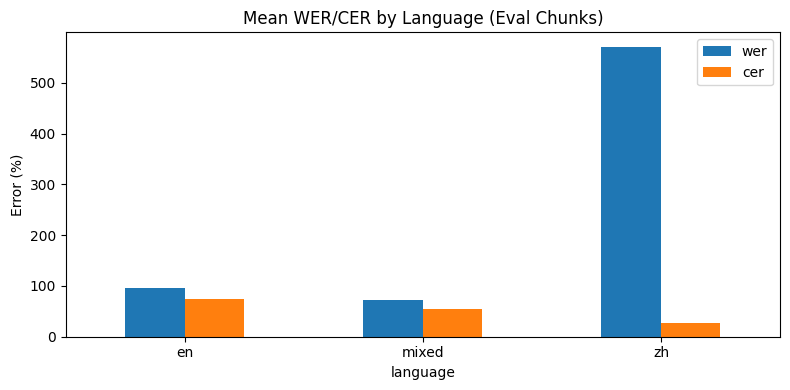

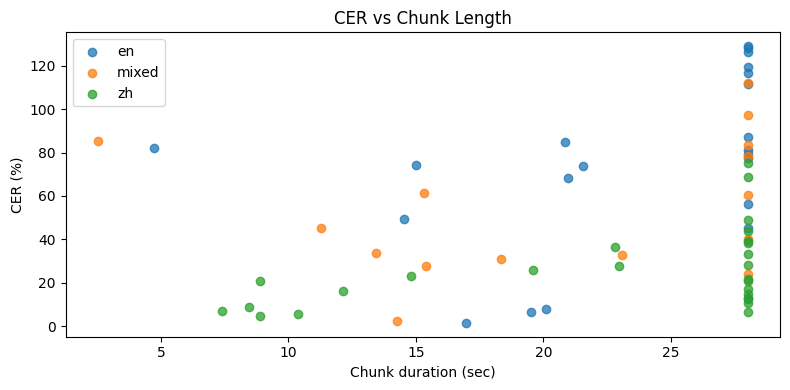


===== EN : 4 example inferences =====

[gold_eval_en_0049_c000] dur=17.0s WER=5.13 CER=1.46
REF : Hi there, this is Modric. I wanted to confirm that my address, Bukit Gombak, was recorded correctly in the system. My phone number is 9504 7098, and my reference ID is 4. Thanks for taking the time to help.
PRED: Hi there, this is Modric. I wanted to confirm that my address is Bukit Gombak, was recorded correctly in the system. My phone number is 9504 7098, and my reference ID is 4. Thanks for taking the time to help.

[gold_eval_en_0044_c000] dur=21.0s WER=100.00 CER=68.27
REF : Hi, this is Marcello. I’m calling because I wasn’t sure if my documents were fully received, so I just wanted to check in. My reference ID is 9. If needed, you can reach me at 8190 8829 or marcello@gmail.com. Thank you for helping to look into this.
PRED: Hai, ini Marcelo. Saya panggil kerana saya tidak yakin jika dokumen saya telah dipercaya. Jadi saya hanya ingin melihat. Ia adalah 9, jika perlukan. Anda dapat 

In [ ]:
# Post-training visualization + sample inferences (4 per language)
import pandas as pd
import matplotlib.pyplot as plt


def _to_wer_tokens_local(s: str) -> str:
    s = (s or '').strip()
    if ' ' not in s:
        return ' '.join(list(s))
    return s


def _decode_single_record(record: dict, max_decode_len: int = 128):
    # Reuse decode policy from the notebook if available
    if 'decode_chunk_record' in globals():
        return decode_chunk_record(record, max_decode_len=max_decode_len)

    # Fallback decode path (should rarely be needed)
    audio_array, sr = load_audio_mono_16k(record['audio_path'])
    s = int(record['start_sec'] * sr)
    e = int(record['end_sec'] * sr)
    chunk = audio_array[s:e]

    feat = processor.feature_extractor(
        chunk,
        sampling_rate=sr,
        return_tensors='pt',
        return_attention_mask=True,
    )
    input_features = feat.input_features.to(model.device)
    attention_mask = feat.attention_mask.to(model.device)

    lang = record['language']
    if lang == 'en':
        forced_decoder_ids = processor.tokenizer.get_decoder_prompt_ids(language='english', task='transcribe')
    elif lang == 'zh':
        forced_decoder_ids = processor.tokenizer.get_decoder_prompt_ids(language='chinese', task='transcribe')
    else:
        forced_decoder_ids = processor.tokenizer.get_decoder_prompt_ids(task='transcribe')

    with torch.no_grad():
        pred_ids = model.generate(
            input_features=input_features,
            attention_mask=attention_mask,
            forced_decoder_ids=forced_decoder_ids,
            max_length=max_decode_len,
            num_beams=5,
        )

    pred = processor.tokenizer.decode(pred_ids[0], skip_special_tokens=True).strip()
    ref = (record['transcript'] or '').strip()
    pred = re.sub(r'\s+', ' ', pred).strip()
    ref = re.sub(r'\s+', ' ', ref).strip()

    return {
        'chunk_id': record.get('chunk_id', ''),
        'record_id': record.get('record_id', ''),
        'language': lang,
        'audio_sec': float(record['end_sec'] - record['start_sec']),
        'ref_text': ref,
        'pred_text': pred,
        'wer': 100 * jiwer_wer([_to_wer_tokens_local(ref)], [_to_wer_tokens_local(pred)]),
        'cer': 100 * jiwer_cer([ref], [pred]),
    }


model.eval()
rows = [_decode_single_record(r) for r in eval_chunks]
df_vis = pd.DataFrame(rows)

print('Per-language mean metrics:')
print(df_vis.groupby('language')[['wer', 'cer']].mean().round(2))

# Plot 1: Mean WER/CER by language
lang_stats = df_vis.groupby('language', as_index=False)[['wer', 'cer']].mean()
ax = lang_stats.plot(x='language', y=['wer', 'cer'], kind='bar', figsize=(8, 4), rot=0)
ax.set_title('Mean WER/CER by Language (Eval Chunks)')
ax.set_ylabel('Error (%)')
plt.tight_layout()
plt.show()

# Plot 2: CER vs chunk duration
fig, ax = plt.subplots(figsize=(8, 4))
for lang, grp in df_vis.groupby('language'):
    ax.scatter(grp['audio_sec'], grp['cer'], label=lang, alpha=0.75)
ax.set_title('CER vs Chunk Length')
ax.set_xlabel('Chunk duration (sec)')
ax.set_ylabel('CER (%)')
ax.legend()
plt.tight_layout()
plt.show()

# Show 4 examples per language (best, 2 middle, worst by CER)
for lang in ['en', 'zh', 'mixed']:
    sub = df_vis[df_vis['language'] == lang].sort_values('cer').reset_index(drop=True)
    if sub.empty:
        continue

    n = len(sub)
    idx = sorted(set([0, n // 3, (2 * n) // 3, n - 1]))
    picks = sub.iloc[idx]

    print(f"\n===== {lang.upper()} : 4 example inferences =====")
    for _, row in picks.iterrows():
        print(f"\n[{row['chunk_id']}] dur={row['audio_sec']:.1f}s WER={row['wer']:.2f} CER={row['cer']:.2f}")
        print('REF :', row['ref_text'][:260])
        print('PRED:', row['pred_text'][:260])

# Save detailed table
out_csv = OUTPUT_DIR / 'eval_predictions_visualization_4_examples.csv'
df_vis.to_csv(out_csv, index=False, encoding='utf-8')
print(f"\nSaved visualization predictions CSV: {out_csv}")
